   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205
   userId  Cluster
0       1        4
1       2        2
2       3        4
3       4        1
4       5        4
Cluster
4    414
1     91
2     88
0     47
3     31
Name: count, dtype: int64


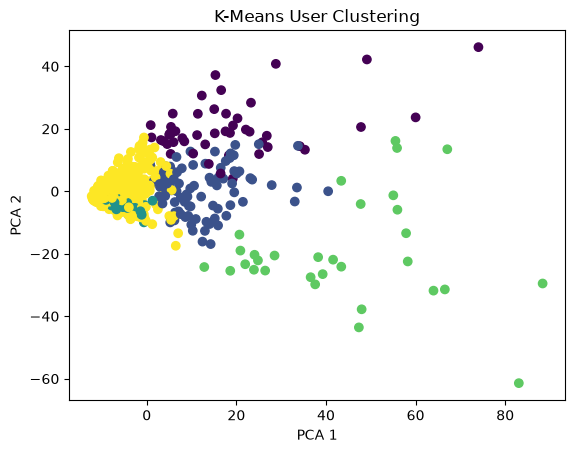

   userId  Cluster
0       1        2
1       2        1
2       3        3
3       4        2
4       5        3


In [1]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# 2. Load dataset
df = pd.read_csv("ratings_small.csv")
print(df.head())

# 3. Create user-movie matrix
data = df.pivot_table(
    index="userId",
    columns="movieId",
    values="rating",
    fill_value=0
)

# 4. K-Means clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(data)

# Add cluster to users
result = pd.DataFrame({
    "userId": data.index,
    "Cluster": clusters
})

print(result.head())

# 5. Cluster sizes
print(result["Cluster"].value_counts())

# 6. Visualise K-Means clusters
pca = PCA(n_components=2)
points = pca.fit_transform(data)

plt.scatter(points[:,0], points[:,1], c=clusters)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means User Clustering")
plt.show()

# 7. NLP
# Convert movie IDs to text for each user
text_data = df.groupby("userId")["movieId"].apply(
    lambda x: " ".join(x.astype(str))
)

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(text_data)

# 8. NLP + K-Means
nlp_kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
nlp_clusters = nlp_kmeans.fit_predict(X)

# 9. Show NLP clusters
nlp_result = pd.DataFrame({
    "userId": text_data.index,
    "Cluster": nlp_clusters
})

print(nlp_result.head())